In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [98]:
data = pd.read_csv("Space_Corrected.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Company Name    4324 non-null   object
 3   Location        4324 non-null   object
 4   Datum           4324 non-null   object
 5   Detail          4324 non-null   object
 6   Status Rocket   4324 non-null   object
 7    Rocket         964 non-null    object
 8   Status Mission  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


Data cleaning

In [99]:
df = data.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], axis=1)
df.columns = ["company", "location", "datum", "detail", "rocket_status", "cost_millions", "mission_status"]
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   company         4324 non-null   object
 1   location        4324 non-null   object
 2   datum           4324 non-null   object
 3   detail          4324 non-null   object
 4   rocket_status   4324 non-null   object
 5   cost_millions   964 non-null    object
 6   mission_status  4324 non-null   object
dtypes: object(7)
memory usage: 236.6+ KB
None


In [100]:
def parse_date(date_str):
  if pd.isna(date_str):
    return pd.NaT

  formats=[
      '%a %b %d, %Y %H:%M',  # Thu Aug 29, 2019 05:12
      '%a %b %d, %Y',        # Thu Aug 29, 2019
      '%b %d, %Y %H:%M',     # Aug 29, 2019 05:12
      '%b %d, %Y',           # Aug 29, 2019
      '%Y-%m-%d %H:%M:%S',   # 2019-08-29 05:12:00
      '%Y-%m-%d',            # 2019-08-29
      '%d %b %Y',            # 29 Aug 2019
      '%d %B %Y',            # 29 August 2019
  ]

  for fmt in formats:
    try:
      return pd.to_datetime(date_str, format=fmt, errors='raise', utc=True)
    except:
      continue
  return pd.to_datetime(date_str, errors='coerce', utc=True)

dates_list = []
for date_str in df['datum']:
    dates_list.append(parse_date(date_str))
df['date'] = dates_list
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

print(df[['date', 'year', 'month', 'day']].head())
print(df.info())

# missing_dates = df['date'].isna().sum()
# total_dates = len(df)
# print(f"All: {total_dates}")
# print(f"Skip: {missing_dates}")
# print(f"Success: {total_dates - missing_dates} ({((total_dates - missing_dates)/total_dates*100):.1f}%)")

# if missing_dates > 0:
#     print("\nFail examples:")
#     problematic = df[df['date'].isna()][['datum', 'date']].head()
#     for idx, row in problematic.iterrows():
#         print(f"Index {idx}: '{row['datum']}'")

                       date  year  month  day
0 2020-08-07 05:12:00+00:00  2020      8    7
1 2020-08-06 04:01:00+00:00  2020      8    6
2 2020-08-04 23:57:00+00:00  2020      8    4
3 2020-07-30 21:25:00+00:00  2020      7   30
4 2020-07-30 11:50:00+00:00  2020      7   30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   company         4324 non-null   object             
 1   location        4324 non-null   object             
 2   datum           4324 non-null   object             
 3   detail          4324 non-null   object             
 4   rocket_status   4324 non-null   object             
 5   cost_millions   964 non-null    object             
 6   mission_status  4324 non-null   object             
 7   date            4324 non-null   datetime64[ns, UTC]
 8   year            4324 non-null   int32     

In [101]:
df['country']=df['location'].str.split(', ').str[-1]
df['country'].unique()

array(['USA', 'China', 'Kazakhstan', 'Japan', 'Israel', 'New Zealand',
       'Russia', 'Shahrud Missile Test Site', 'France', 'Iran', 'India',
       'New Mexico', 'Yellow Sea', 'North Korea',
       'Pacific Missile Range Facility', 'Pacific Ocean', 'South Korea',
       'Barents Sea', 'Brazil', 'Gran Canaria', 'Kenya', 'Australia'],
      dtype=object)

In [103]:
print("Null values")
print(df.isnull().sum())

df['cost_millions'] = df['cost_millions'].astype(str).str.strip()
df['cost_millions'] = df['cost_millions'].replace('', np.nan)
df['cost_millions'] = pd.to_numeric(df['cost_millions'], errors='coerce')

q1 = df['cost_millions'].quantile(q=0.25)
q3 = df['cost_millions'].quantile(q=0.75)
mask = df['cost_millions'].isna()
df.loc[mask, 'cost_millions'] = np.random.uniform(q1, q3, size=mask.sum())
print(f"Median cost: {df['cost_millions'].mean():.2f} * 1000000 $")

Null values
company           0
location          0
datum             0
detail            0
rocket_status     0
cost_millions     0
mission_status    0
date              0
year              0
month             0
day               0
country           0
dtype: int64
Median cost: 107.08 * 1000000 $


In [21]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   company         4324 non-null   object             
 1   location        4324 non-null   object             
 2   datum           4324 non-null   object             
 3   detail          4324 non-null   object             
 4   rocket_status   4324 non-null   object             
 5   cost_millions   4324 non-null   float64            
 6   mission_status  4324 non-null   object             
 7   date            4324 non-null   datetime64[ns, UTC]
 8   year            4324 non-null   int32              
 9   month           4324 non-null   int32              
 10  day             4324 non-null   int32              
dtypes: datetime64[ns, UTC](1), float64(1), int32(3), object(6)
memory usage: 321.1+ KB


Analyze data

In [22]:
total_missions = len(df)
first_year = df['year'].min()
last_year = df['year'].max()
print(f"Total missions: {total_missions}")
print(f"First launch: {first_year}")
print(f"Last launch: {last_year}")
print(f"Duration: {last_year-first_year}")
print()
avg_launches_per_year = total_missions / (last_year-first_year)
print(f"Average quantity of launches per year: {avg_launches_per_year:.1f}")
print()

yearly_counts = df['year'].value_counts()
top_years = yearly_counts.head()

print("Top 5 years by launches")
for year, count in top_years.items():
  print(f"In {year} there was {count} launches")

Total missions: 4324
First launch: 1957
Last launch: 2020
Duration: 63

Average quantity of launches per year: 68.6

Top 5 years by launches
In 1971 there was 119 launches
In 2018 there was 117 launches
In 1977 there was 114 launches
In 1975 there was 113 launches
In 1976 there was 113 launches


Analyzing activity (Count of launches)

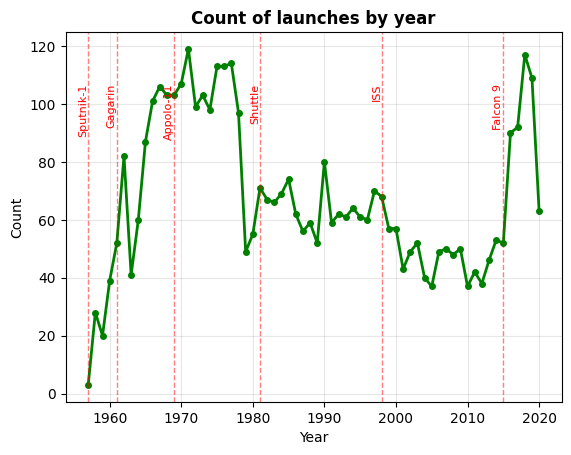

In [23]:
years_sorted = sorted(yearly_counts.index)
counts_sorted = [yearly_counts[year] for year in years_sorted]

plt.plot(years_sorted, counts_sorted, 'g-', linewidth=2, marker='o', markersize=4)
plt.title("Count of launches by year", fontsize=12, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)

milestones = {
    1957: "Sputnik-1",
    1961: "Gagarin",
    1969: "Appolo-11",
    1981: "Shuttle",
    1998: "ISS",
    2015: "Falcon 9"
}

for year, event in milestones.items():
  if year in yearly_counts.index:
    plt.axvline(x=year, color="red", linestyle="--", alpha=0.5, linewidth=1)
    plt.text(year, max(counts_sorted)*0.9, event,
             rotation=90, va="top", ha="right", fontsize=8, color="red")

<h1>Conclusion:</h1> Peak in the 1960s-70s (USSR-USA race) and new growth in the 2010s (SpaceX and private space).

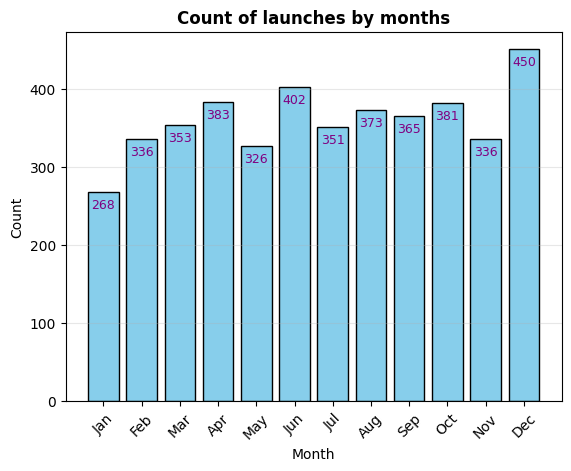

In [24]:
monthly_counts = df['month'].value_counts().sort_index()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
bars = plt.bar(range(1, 13), monthly_counts.values, color="skyblue", edgecolor="black")
plt.title("Count of launches by months", fontsize=12, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1, 13), month_names, rotation=45)

for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x()+bar.get_width()/2, height-25, f"{int(height)}", ha="center", va="bottom", fontsize=9, color="purple")

plt.grid(True, alpha=0.3, axis="y")

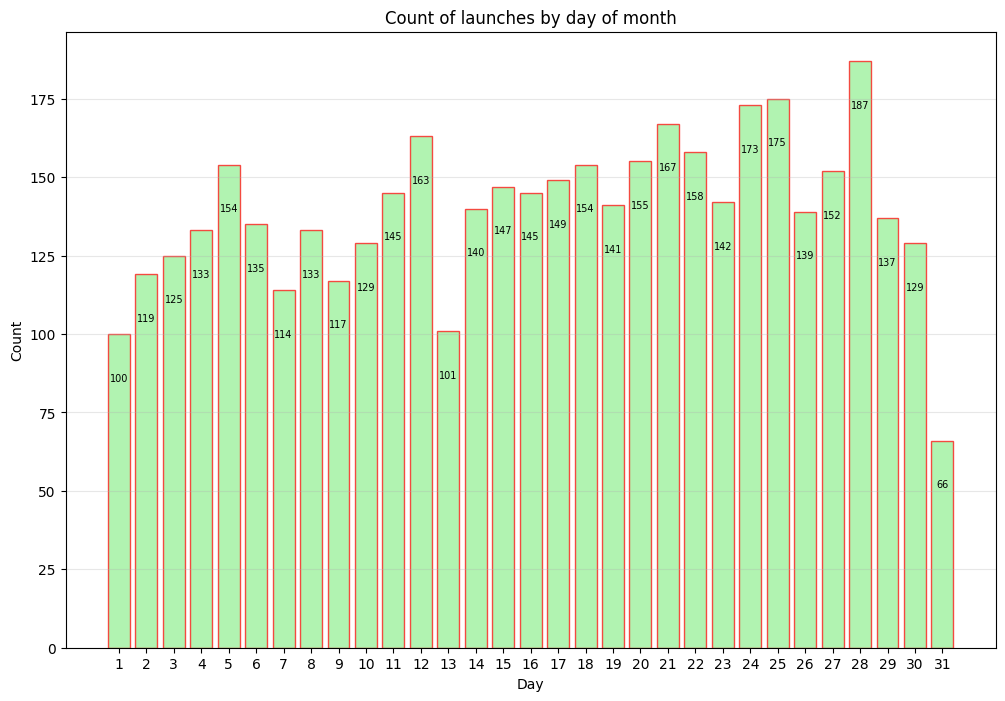

In [25]:
plt.figure(figsize=(12,8))
day_counts = df["day"].value_counts().sort_index()
bars=plt.bar(day_counts.index, day_counts.values, color="lightgreen", edgecolor="red", alpha=0.7)
plt.xlabel("Day")
plt.ylabel("Count")
plt.title("Count of launches by day of month")
plt.xticks(day_counts.index, day_counts.index)

for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x()+bar.get_width()/2, height-15, f"{int(height)}", ha="center", fontsize=7, color="black")


plt.grid(True, alpha=0.3, axis="y")

In [181]:
top_15_companies_names = df['company'].value_counts().nlargest(15).index
top_15_companies = df[df['company'].isin(top_15_companies_names)]
data_companies = top_15_companies['company'].value_counts().sort_values(ascending=True)

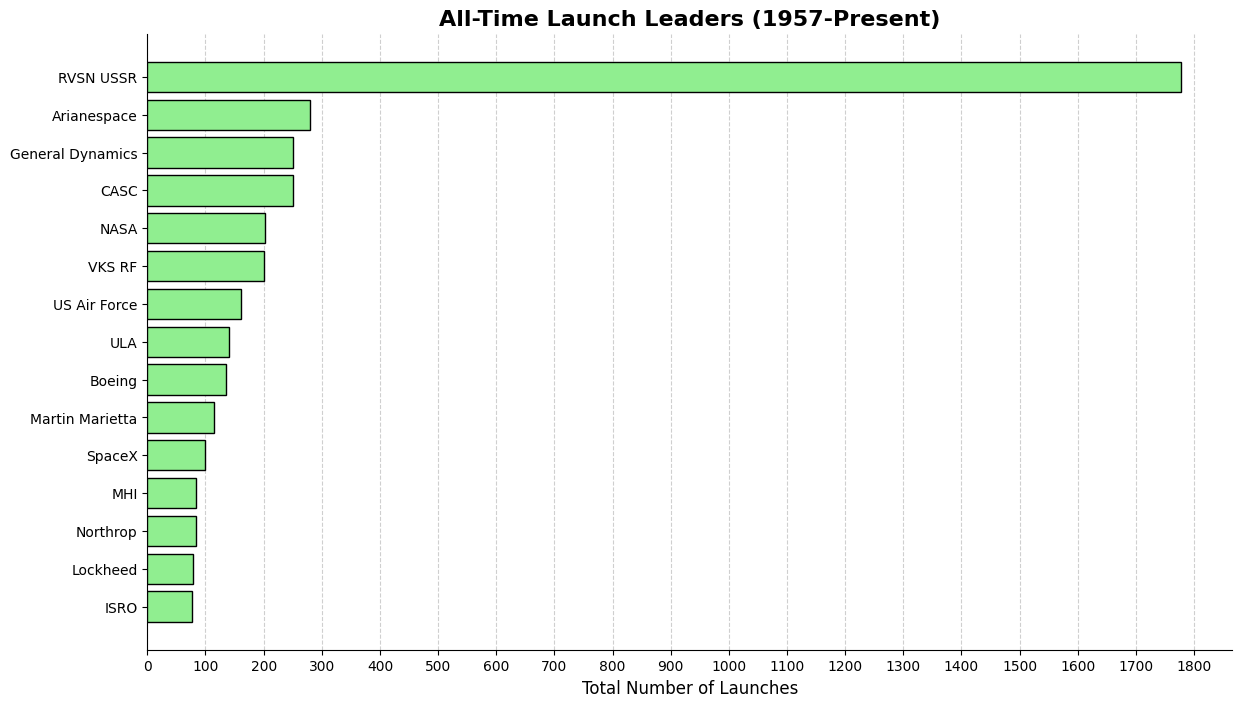

In [191]:
plt.figure(figsize=(14, 8))

plt.barh(data_companies.index, data_companies.values, color="lightgreen", edgecolor="black", zorder=3)

plt.title('All-Time Launch Leaders (1957-Present)', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Launches', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6, zorder=0)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.xticks(np.arange(0, data_companies.values.max()+100, 100))

plt.show()

<h1>Conclusion: </h1> The visualization highlights the historical dominance of the RVSN USSR, which remains the all-time leader in launch volume, significantly outpacing all contemporary commercial and state-run aerospace entities.


Visualizing cost of launches

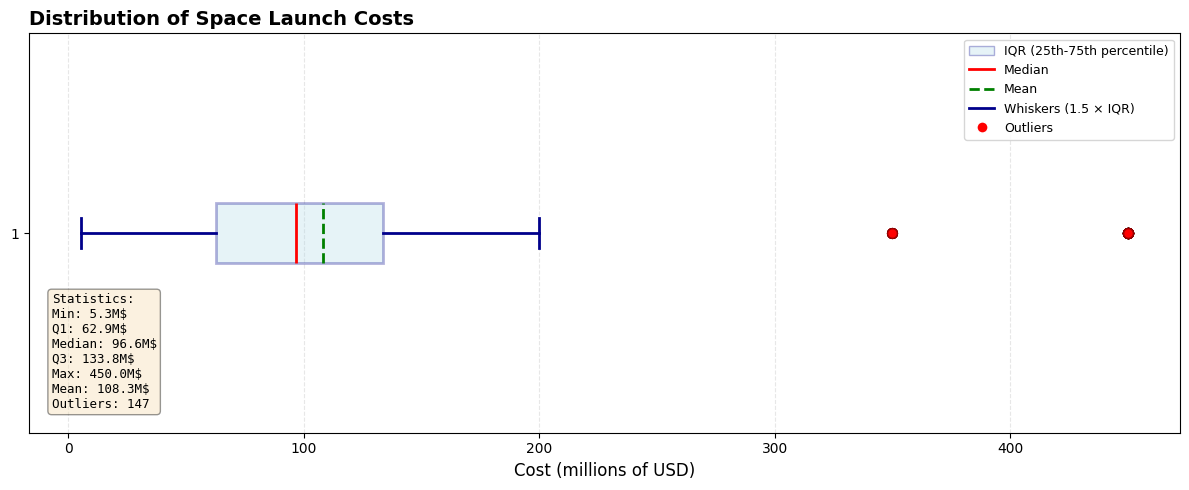

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

data = df['cost_millions'].dropna().values
plt.figure(figsize=(12, 5))
plt.boxplot(data,
            vert=False,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            whis=1.5,
            boxprops=dict(facecolor='lightblue', color='darkblue', linewidth=2, alpha=0.3),
            whiskerprops=dict(color='darkblue', linewidth=2),
            capprops=dict(color='darkblue', linewidth=2),
            medianprops=dict(color='red', linewidth=2),
            meanprops=dict(color='green', linestyle='--', linewidth=2),
            flierprops=dict(marker='o', alpha=0.6, markersize=7,
                           markerfacecolor='red', markeredgecolor='darkred'),
            showfliers=True)

plt.title("Distribution of Space Launch Costs", fontsize=14, fontweight='bold', loc='left')
plt.xlabel("Cost (millions of USD)", fontsize=12)
plt.grid(True, alpha=0.3, axis="x", linestyle='--')

legend_elements = [
    Patch(facecolor='lightblue', edgecolor='darkblue', alpha=0.3, label='IQR (25th-75th percentile)'),
    Line2D([0], [0], color='red', lw=2, label='Median'),
    Line2D([0], [0], color='green', lw=2, ls='--', label='Mean'),
    Line2D([0], [0], color='darkblue', lw=2, label='Whiskers (1.5 × IQR)'),
    Line2D([0], [0], marker='o', color='w', label='Outliers',
           markerfacecolor='red', markersize=8)
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9)

q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = data[(data < lower_bound) | (data > upper_bound)]
n_outliers = len(outliers)

stats_text = (
    f"Statistics:\n"
    f"Min: {data.min():.1f}M$\n"
    f"Q1: {np.percentile(data, 25):.1f}M$\n"
    f"Median: {np.median(data):.1f}M$\n"
    f"Q3: {np.percentile(data, 75):.1f}M$\n"
    f"Max: {data.max():.1f}M$\n"
    f"Mean: {data.mean():.1f}M$\n"
    f"Outliers: {n_outliers}"
)

plt.text(0.02, 0.35, stats_text, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.tight_layout()
plt.show()


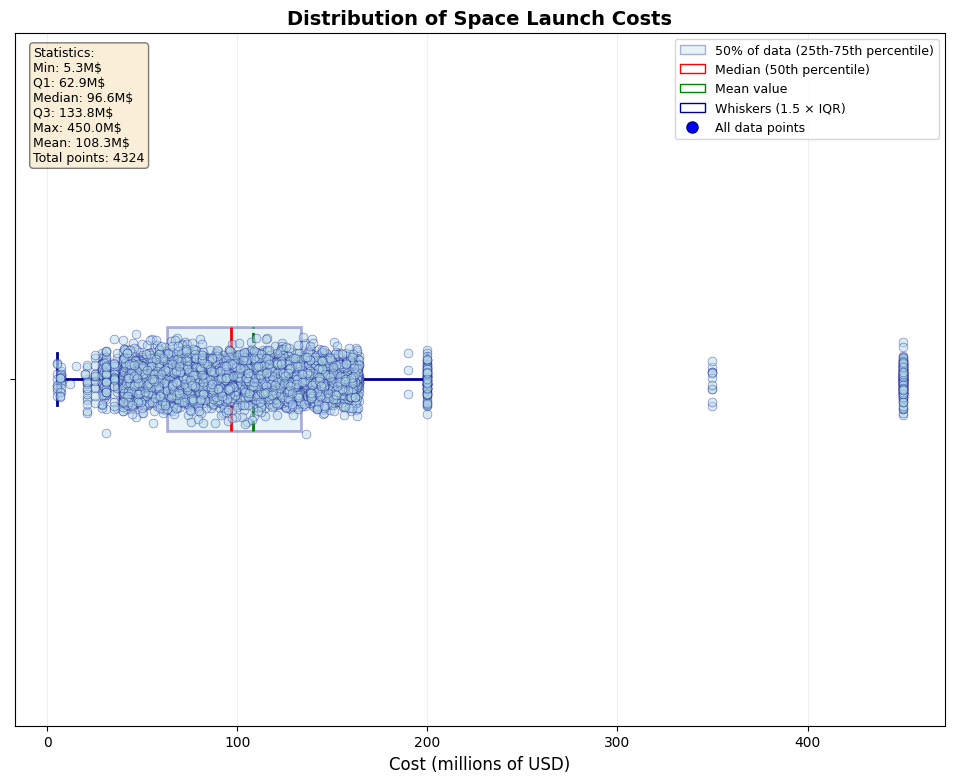

In [39]:
data = df['cost_millions'].dropna().values
plt.figure(figsize=(12,9))
boxplot = plt.boxplot(data, vert=False, patch_artist=True,
                      showmeans=True, meanline=True,
                      whis=1.5,
                      boxprops=dict(facecolor='lightblue', color='darkblue', linewidth=2, alpha=0.3),
                      whiskerprops=dict(color='darkblue', linewidth=2),
                      capprops=dict(color='darkblue', linewidth=2),
                      medianprops=dict(color='red', linewidth=2),
                      meanprops=dict(color='green', linestyle='--', linewidth=2),
                      flierprops=dict(marker='', alpha=0),
                      showfliers=False)

np.random.seed(42)
y_jitter = 1 - np.random.normal(0, 0.02, size=len(data))

plt.scatter(data, y_jitter, alpha=0.45, s=40,
            color='lightblue', edgecolors='darkblue', linewidth=0.5,
            label='All data points', zorder=5)

plt.title("Distribution of Space Launch Costs", fontsize=14, fontweight='bold')
plt.xlabel("Cost (millions of USD)", fontsize=12)
plt.yticks([1], [''])
plt.grid(True, alpha=0.2, axis="x")

legend_elements = [
    Patch(facecolor='lightblue', edgecolor='darkblue', alpha=0.3,
          label='50% of data (25th-75th percentile)'),
    Patch(facecolor='white', edgecolor='red',
          label='Median (50th percentile)'),
    Patch(facecolor='white', edgecolor='green',
          label='Mean value'),
    Patch(facecolor='white', edgecolor='darkblue',
          label='Whiskers (1.5 × IQR)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
               markeredgecolor='darkblue', markersize=8, label='All data points')
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=9)

stats_text = f"""Statistics:
Min: {data.min():.1f}M$
Q1: {np.percentile(data, 25):.1f}M$
Median: {np.median(data):.1f}M$
Q3: {np.percentile(data, 75):.1f}M$
Max: {data.max():.1f}M$
Mean: {data.mean():.1f}M$
Total points: {len(data)}"""

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

In [144]:
top_10_companies = df.groupby("company").size().nlargest(10).index
df_top_data = df[df['company'].isin(top_10_companies)].dropna(subset=['cost_millions'])
# print(df_top_data)
# print(df_top_data.groupby('company')['cost_millions'].sum())
avg_costs=df_top_data.groupby('company')['cost_millions'].mean().sort_values(ascending=False)
print(avg_costs)

company
NASA                333.160904
ULA                 137.815008
Arianespace         124.407999
Boeing              106.838795
RVSN USSR           100.565378
Martin Marietta     100.198337
General Dynamics     99.743033
VKS RF               91.768520
US Air Force         88.610218
CASC                 64.357705
Name: cost_millions, dtype: float64


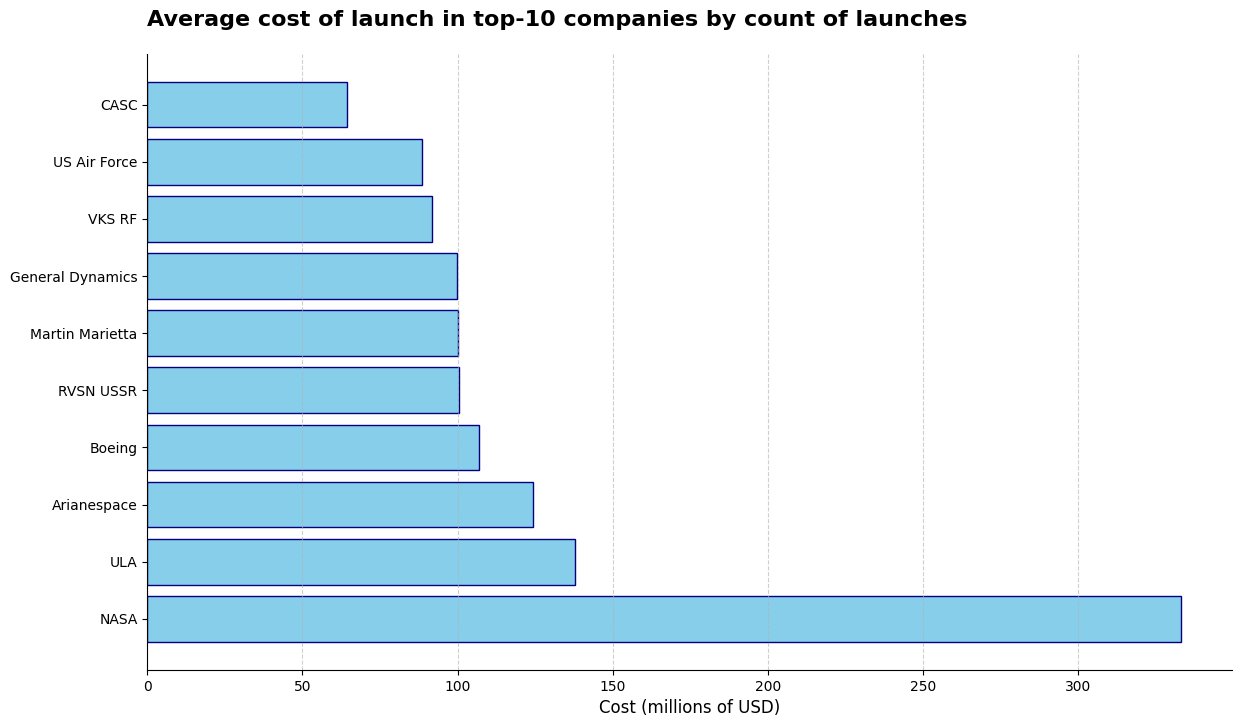

In [152]:
plt.figure(figsize=(14, 8))
plt.barh(avg_costs.index, avg_costs.values, color='skyblue', edgecolor='navy')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title("Average cost of launch in top-10 companies by count of launches", fontsize=16, fontweight='bold', pad=20, loc='left')
plt.xlabel('Cost (millions of USD)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

/tmp/ipython-input-1073332392.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_to_plot, vert=False, patch_artist=True,


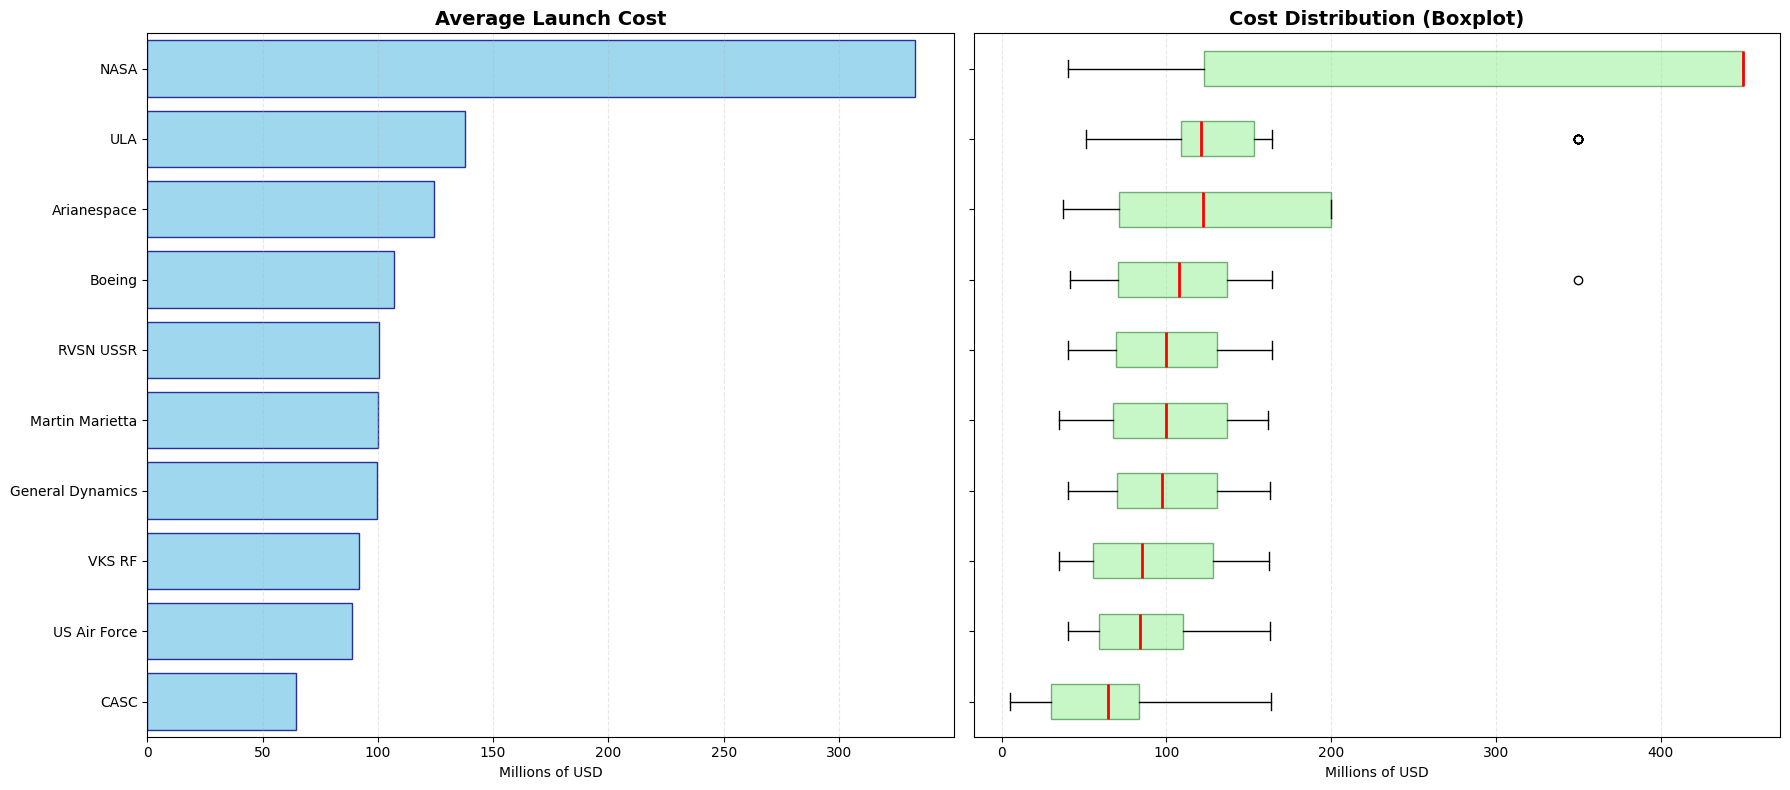

In [161]:
data_to_plot = [df_top_data[df_top_data['company'] == name]['cost_millions'] for name in avg_costs.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

y_positions = np.arange(len(avg_costs))
ax1.barh(y_positions, avg_costs.values, color='skyblue', edgecolor='navy', alpha=0.8)
ax1.set_title('Average Launch Cost', fontsize=14, fontweight='bold')
ax1.set_xlabel('Millions of USD')
ax1.invert_yaxis()
ax1.grid(axis='x', linestyle='--', alpha=0.3)

ax2.boxplot(data_to_plot, vert=False, patch_artist=True,
            labels=avg_costs.index,
            positions=y_positions,
            boxprops=dict(facecolor='lightgreen', color='darkgreen', alpha=0.5),
            medianprops=dict(color='red', linewidth=2))
ax2.set_title('Cost Distribution (Boxplot)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Millions of USD')
ax2.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


<h1>Conclusion: </h1> The visualizations indicate that average launch costs range widely from under $100 million USD for CASC to over $300 million USD for NASA, with most key operators clustering around the $100–$150 million mark, highlighting significant variance in pricing strategies and mission scope across the industry.

Analyzing confrontation of countries (USSR vs. USA vs. Others)

In [89]:
data = df.groupby(["year", "country"]).size().unstack(level=1)
top_5 = data.sum().nlargest(5).index

print(top_5)
filtered_data = data[top_5].fillna(0)
print(filtered_data)

Index(['Russia', 'USA', 'Kazakhstan', 'France', 'China'], dtype='object', name='country')
country  Russia   USA  Kazakhstan  France  China
year                                            
1957        0.0   1.0         2.0     0.0    0.0
1958        0.0  23.0         5.0     0.0    0.0
1959        0.0  16.0         4.0     0.0    0.0
1960        0.0  30.0         9.0     0.0    0.0
1961        2.0  43.0         7.0     0.0    0.0
...         ...   ...         ...     ...    ...
2016        6.0  27.0        11.0    11.0   22.0
2017        6.0  30.0        13.0    11.0   18.0
2018        8.0  33.0         9.0    11.0   39.0
2019        9.0  24.0        13.0     9.0   33.0
2020        3.0  21.0         6.0     2.0   22.0

[64 rows x 5 columns]


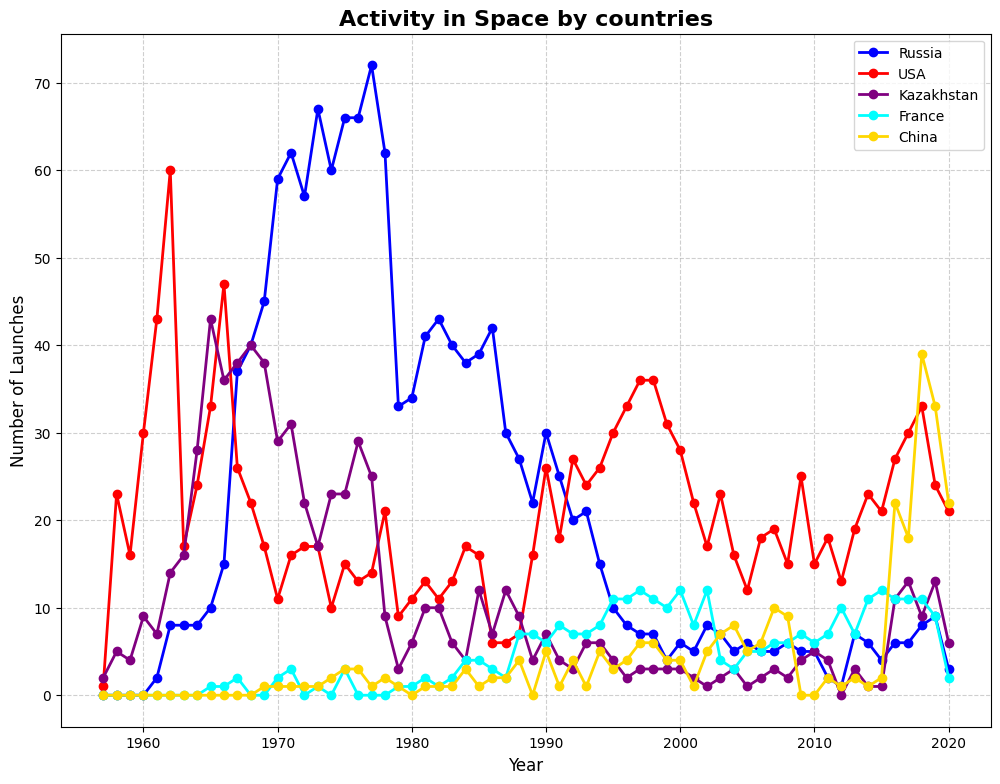

In [90]:
plt.figure(figsize=(12,9))

plt.plot(filtered_data.index, filtered_data["Russia"], label="Russia", color="blue", linewidth=2, marker="o")
plt.plot(filtered_data.index, filtered_data["USA"], label="USA", color="red", linewidth=2, marker="o")
plt.plot(filtered_data.index, filtered_data["Kazakhstan"], label="Kazakhstan", color="purple", linewidth=2 , marker="o")
plt.plot(filtered_data.index, filtered_data["France"], label="France", color="cyan", linewidth=2, marker="o")
plt.plot(filtered_data.index, filtered_data["China"], label="China", color="gold", linewidth=2, marker="o")

plt.title('Activity in Space by countries', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

plt.show()

<h1>Conclusion:</h1> Shift from the mid-century bipolar rivalry between the USSR and USA to a modern, multi-polar era characterized by China's rapid ascent and a resurgence in US launch activity driven by the private sector.


Analyzing mission status

In [107]:
mapping = {
    "Partial Failure" : "Failure",
    "Prelaunch Failure" : "Failure"
}
data = df.copy()
data['mission_status'] = data['mission_status'].replace(mapping)
data = data.pivot_table(index="year", columns="mission_status", aggfunc="size").fillna(0)

data_percents = data.div(data.sum(axis=1), axis = 0)

print(data_percents)

mission_status   Failure   Success
year                              
1957            0.333333  0.666667
1958            0.785714  0.214286
1959            0.600000  0.400000
1960            0.512821  0.487179
1961            0.384615  0.615385
...                  ...       ...
2016            0.044444  0.955556
2017            0.086957  0.913043
2018            0.034188  0.965812
2019            0.082569  0.917431
2020            0.095238  0.904762

[64 rows x 2 columns]


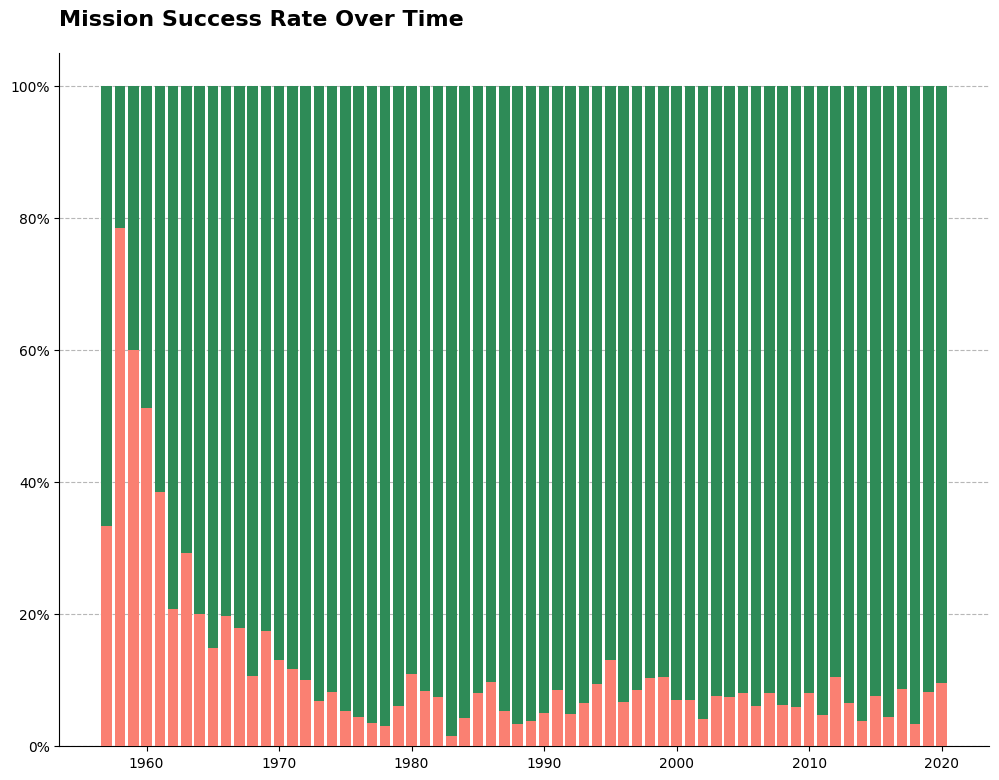

In [120]:
import matplotlib.ticker as mtick

plt.figure(figsize=(12,9))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.grid(axis='y', linestyle='--', alpha=0.9, zorder=0)

bars_failure = plt.bar(data_percents.index, data_percents["Failure"], color="salmon", zorder=3)
bars_success = plt.bar(data_percents.index, data_percents["Success"], color="seagreen", bottom=data_percents["Failure"], zorder=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title("Mission Success Rate Over Time", fontsize=16, fontweight='bold', pad=20, loc='left')

plt.show()

<h1>Conclusion: </h1> Significant evolution in aerospace reliability, transitioning from the volatile failure rates of the early Space Race in the 1950s and 60s to a highly stabilized success rate exceeding 90% in the modern era.

<h1>Final Project Summary: Analysis of the Space Race (1957–2020)</h1>
The analysis shows that the "space race" has changed significantly over time.
History: We have moved from the competition between the US and the USSR during the Cold War to a modern market dominated by China and private American companies like SpaceX.
Reliability: Rockets have become much safer. While failures were common in the past, today more than 90% of launches are successful.
Cost: Prices vary greatly. NASA is the most expensive organization, while newer players offer much lower prices, making space more accessible.